# Estudio de algoritmos basados en Upper Confidence Bounds en el problema k-armed bandits

*Description:* El experimento compara el rendimiento de algoritmos UCB en un problema de k-armed bandit. Se estudian los algoritmos UCB1 y UCB2, se generan distintas gráficas para evaluar la eficacia de ambos.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06

## Preparación del entorno

In [1]:
#!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
#!cd k_brazos/

In [2]:
import sys
sys.path.append('/content/k_brazos/src')

In [3]:
from algorithms import UCB1, UCB2
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret
from utils import run_experiment

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
seed = 42
np.random.seed(seed)

## Ejecución del experimento

Se realizan tres experimentos, evaluando en cada uno de ellos los rendimientos de los algoritmos UCB1 y UCB2 para varios valores de sus parámetros. las pruebas de los dos algoritmos de UCB en tres distribuciones: normal, binomial y Bernoulli.

En estos experimentos nos interesa estudiar dos aspectos principales. El primero es comparar los desempeños de cada algoritmo para distintos valores de sus parámetros. El segundo es estudiar como variar la distribución usada por cada brazo afecta a las recompensas obtenidas. Para esto, buscamos fijar la mayor parte de variables entre experimentos, para reducir así fuentes de variación que afecten a los resultados. De esta forma los tres experimentos comparten las siguientes características:
- En los tres experimentos trabajaremos con un bandido de 10 brazos.
- Realizaremos siempre 1000 pasos (elecciones de brazo) en cada ejecución, con 500 ejecuciones por experimento para obtener resultados estadísticamente significativos.
- Para asegurar condiciones justas en los experimentos, trabajaremos siempre con el mismo conjunto de 10 medias, independientemente del experimento. Es decir, entre experimentos, las distribuciones de los brazos del bandido cambian, pero sus medias no.
- Usaremos siempre los mismos algoritmos con los mismos parámetros. Los primeros 3 son UCB1, con distintos valores en su parámetro de exploración (0.5, 1, 2). Los otros 3 son UCB2, con prámetros de exploración 0.1, 0.5 y 0.9.

In [5]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos
runs = 1  # Número de ejecuciones
means = np.random.uniform(0.1, 1, k)  # Medias aleatorias para los brazos
# Algoritmos para comparar
algorithms = [
                UCB2(k=k, alpha=0.1), 
                UCB2(k=k, alpha=0.5), 
                UCB2(k=k, alpha=0.9),
            ]

### Experimento 1: Distribución normal

Empezamos evaluando los dos algoritmos en un bandido cuyos brazos siguen distribuciones normales, con sigma 1 y medias aleatorias distribuidas uniformemente entre 1 y 10.

Generamos el bandido y ejecutamos el experimento.

In [6]:
bandit = Bandit(arms=ArmNormal.generate_arms_with_fixed_means(means=means*10, sigma=1.0))
# bandit = Bandit(arms=ArmBernoulli.generate_arms(k, scale = 10))  
# bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=10, scale = 1))
print(bandit)

# Obtiene el brazo óptimo para pasarlo a la gráfica
optimal_arm_index = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm_index + 1} with expected reward={bandit.get_expected_value(optimal_arm_index)}")

# Ejecuta el experimento y obtiene las recompensas promedio y selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)



Bandit with 10 arms: ArmNormal(mu=4.370861069626263, sigma=1.0), ArmNormal(mu=9.556428757689247, sigma=1.0), ArmNormal(mu=7.587945476302646, sigma=1.0), ArmNormal(mu=6.387926357773329, sigma=1.0), ArmNormal(mu=2.4041677639819286, sigma=1.0), ArmNormal(mu=2.403950683025824, sigma=1.0), ArmNormal(mu=1.5227525095137953, sigma=1.0), ArmNormal(mu=8.795585311974417, sigma=1.0), ArmNormal(mu=6.41003510568888, sigma=1.0), ArmNormal(mu=7.372653200164409, sigma=1.0)
Optimal arm: 2 with expected reward=9.556428757689247
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
0
3
0
1
2
0
0
1
0
2
0
0
1
0
0
0
1
0
0
0
0
3
3
0
2
2
0
1
1
0
0
0
0
0
6
0
5
5
0
4
4
0
3
3
0
2
2
0
1
1
0
0
0
0
1
11
0
0
10
0
8
9
0
7
8
0
6
7
0
5
6
0
4
5
0
3
4
0
2
3
0
1
2
0
0
1
0
1
0
0
0
22
0
2
21
0
1
20
0
0
19
0
12
18
0
11
17
0
10
16
0
9
15
0
8
14
0
7
13
0
6
12
0
5
11
0
4
10
1
3
9
0
2
8
1
1
7
0
0
6
1
19
5
0
18
4
1
17
3
0
16
2
1
15
1
0
14
0
1
13
42
0
12
41
1
11
40
0
10
39
2
9
38
1
8
37
0
7
36
2
6
35

Los brazos generados tienen medias [4.37, 9.56, 7.59, 6.39, 2.40, 2.40, 1.52, 8.80, 6.41, 7.37]. Tenemos que el brazo óptimo es el segundo, con una recompensa media de 9.56.

Mostramos ahora la recompensa media obtenida por cada algoritmo.

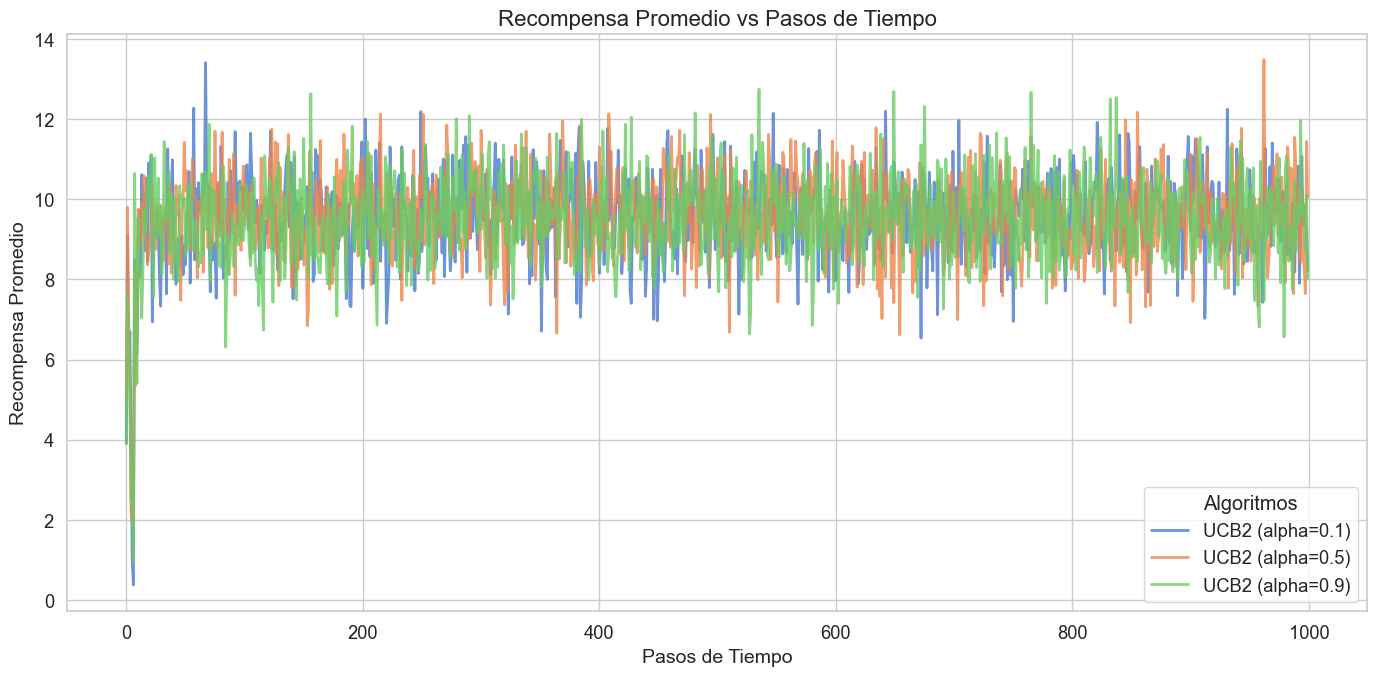

In [7]:
plot_average_rewards(steps, rewards, algorithms)


Como ya se ha comentado en otros notebooks, los 10 primeros pasos deben estudiarse de forma separada al resto, puesto que son los pasos en los que todos los algoritmos realizan una exploración inicial, probando cada uno de los 10 brazos 1 vez en orden ascendente.

De hecho, si mostramos únicamente los 10 primeros pasos, se aprecia claramente que todos los algoritmos obtienen en el paso k una recompensa aproximadamente igual a la media del brazo k. Esto es cierto en todos los experimentos del notebook, así como en los demás notebooks cuyos algoritmos realizan esta pasada inicial.

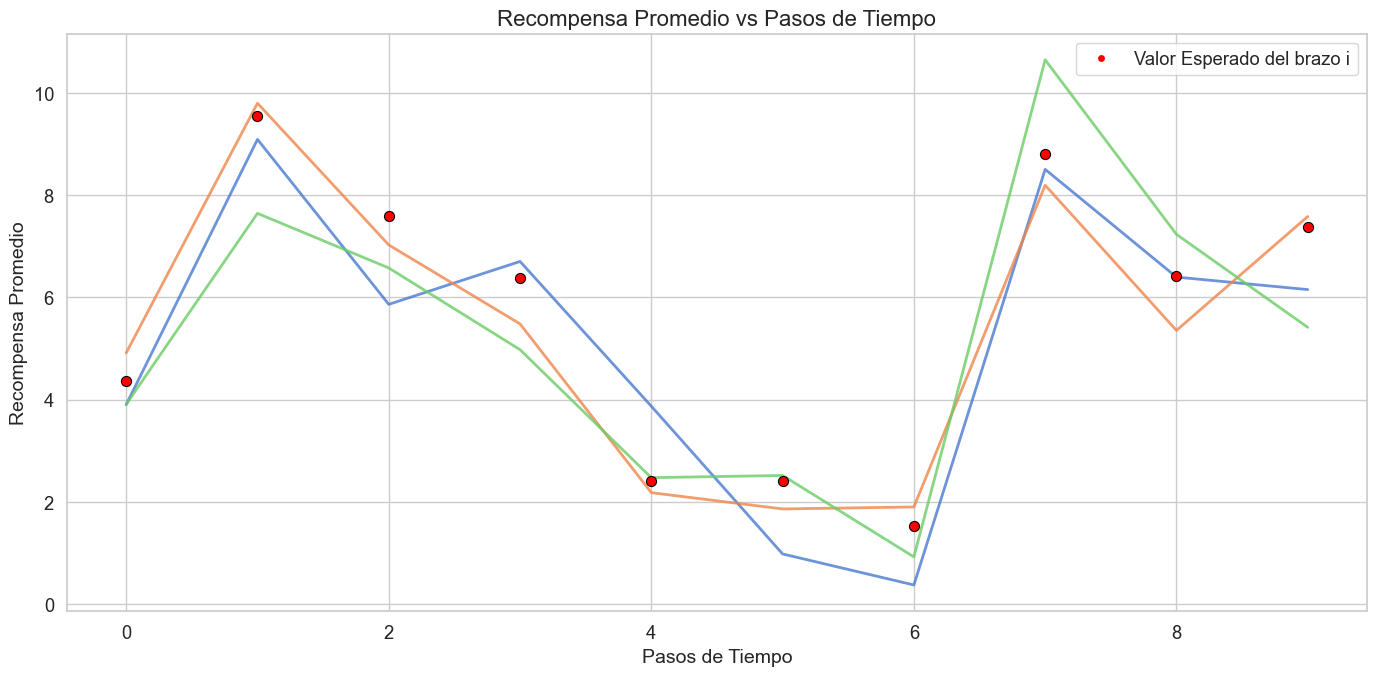

In [8]:
def aux_plot(steps, rewards, algorithms):
    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
    plt.figure(figsize=(14, 7))

    for i, arm in enumerate(bandit.arms):
        expected_val = arm.get_expected_value()
        plt.scatter(i, expected_val, color='black', s=50, zorder=5) 
        plt.scatter(i, expected_val, color='red', s=30, zorder=5) 

    for idx, algo in enumerate(algorithms):
        plt.plot(range(steps), rewards[idx], linewidth=2, alpha=0.8)

    plt.xlabel('Pasos de Tiempo', fontsize=14)
    plt.ylabel('Recompensa Promedio', fontsize=14)
    plt.title('Recompensa Promedio vs Pasos de Tiempo', fontsize=16)

    # Add a custom legend entry for the expected values if desired
    from matplotlib.lines import Line2D
    handles, labels = plt.gca().get_legend_handles_labels()
    line = Line2D([0], [0], marker="o", color='w', markerfacecolor='red', label='Valor Esperado del brazo i')
    handles.append(line)

    plt.legend(handles=handles)
    plt.tight_layout()
    plt.show()
aux_plot(10, rewards[:, 0:10], algorithms)

Centrandonos en el resto de pasos gráficas podemos comprobar las diferencias entre algoritmos con algo más de claridad. Parece que los UCB2 obtienen siempre resultados mejores que los UCB1. Independientemente del valor del parámetro de exploración, los UCB2 se comportan todos igual. Los UCB1, sin embargo, sí parecen beneficiarse de un parámetro de exploración cercano a 1.

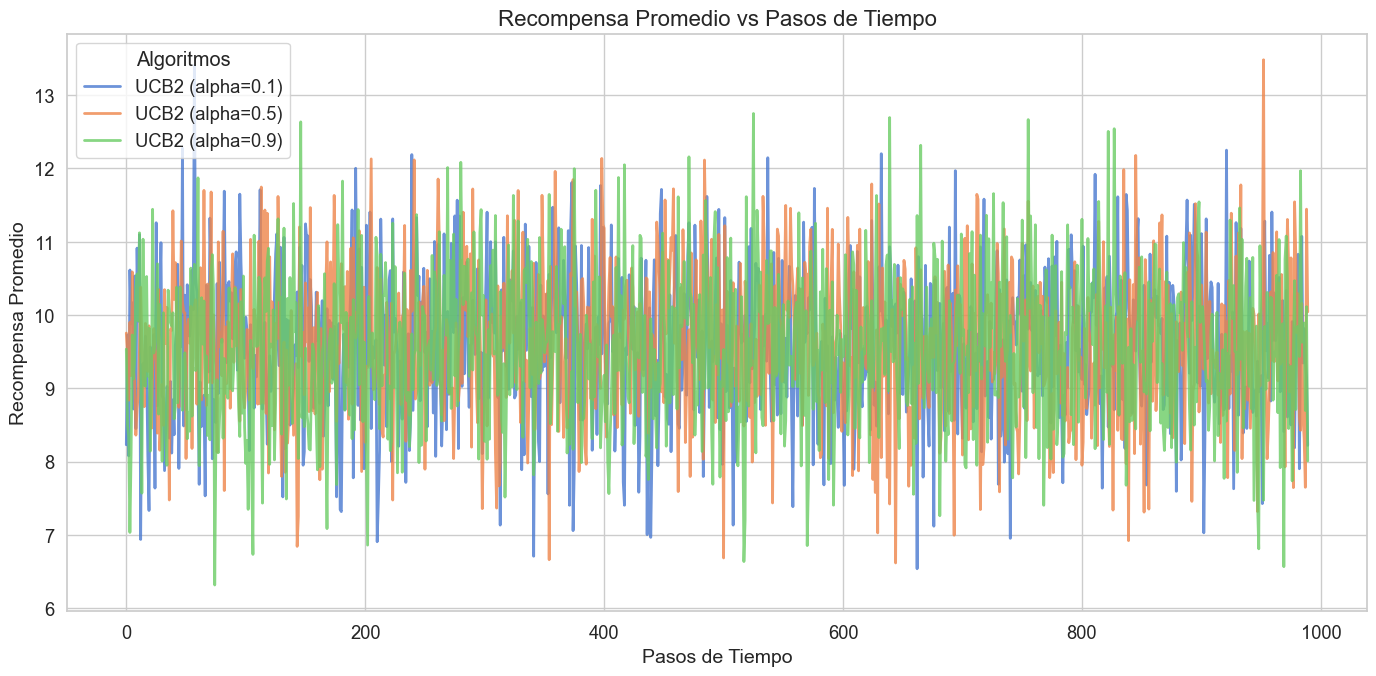

In [9]:
plot_average_rewards(steps-10, rewards[:, 10:], algorithms)

Por terminar, falta un factor de 10 por ahi

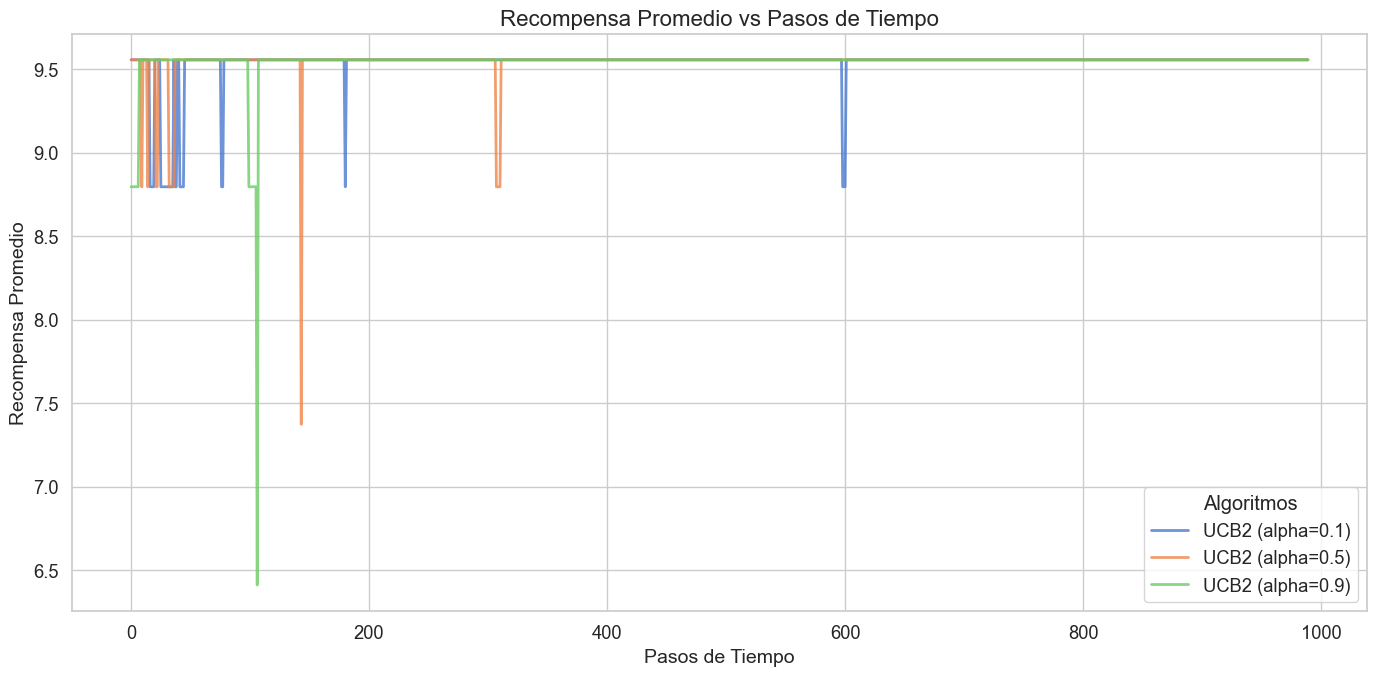

In [10]:
import numpy as np
theoretical_rewards = np.zeros((len(algorithms), steps))
for idx, algo in enumerate(algorithms):
    for step in range(steps):
        theoretical_rewards[idx, step] = np.sum([arms_stats[idx]['chosen_arms'][arm_idx][step] * bandit.arms[arm_idx].get_expected_value() for arm_idx in range(k)])/runs

plot_average_rewards(steps-10, theoretical_rewards[:, 10:], algorithms)

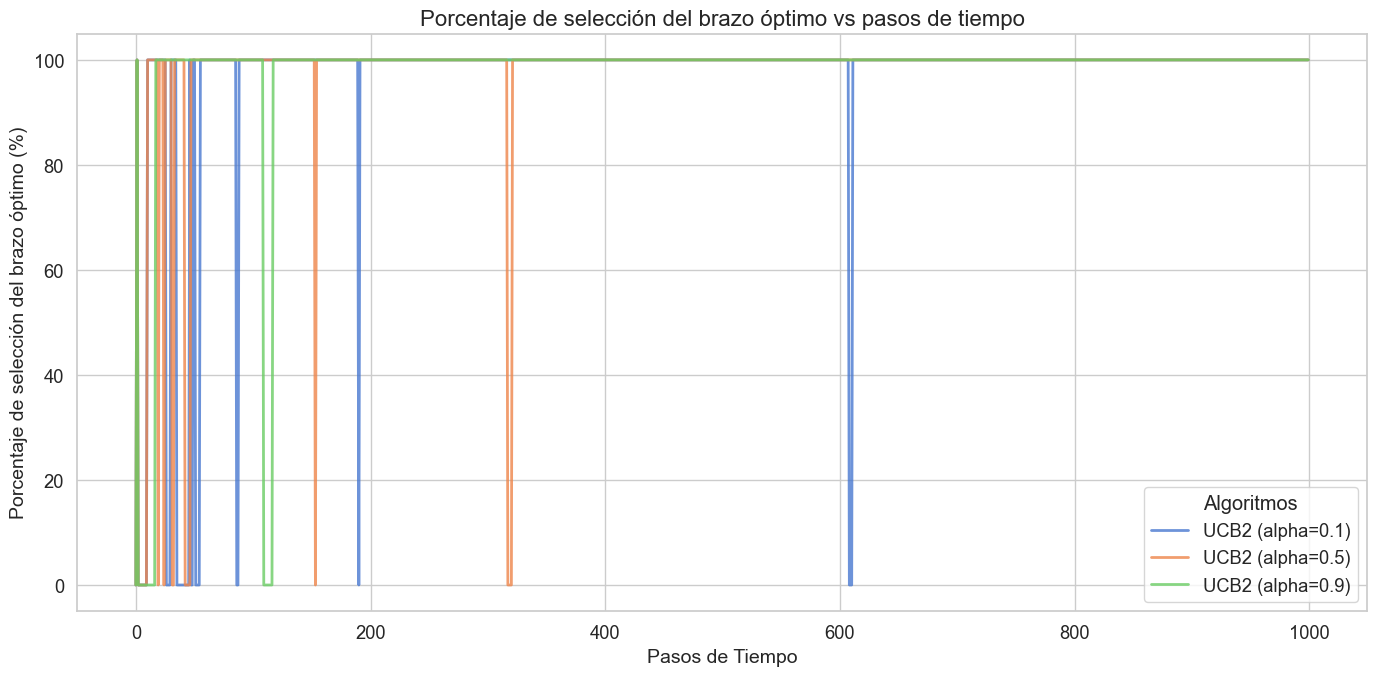

In [11]:
plot_optimal_selections(steps, optimal_selections, algorithms)


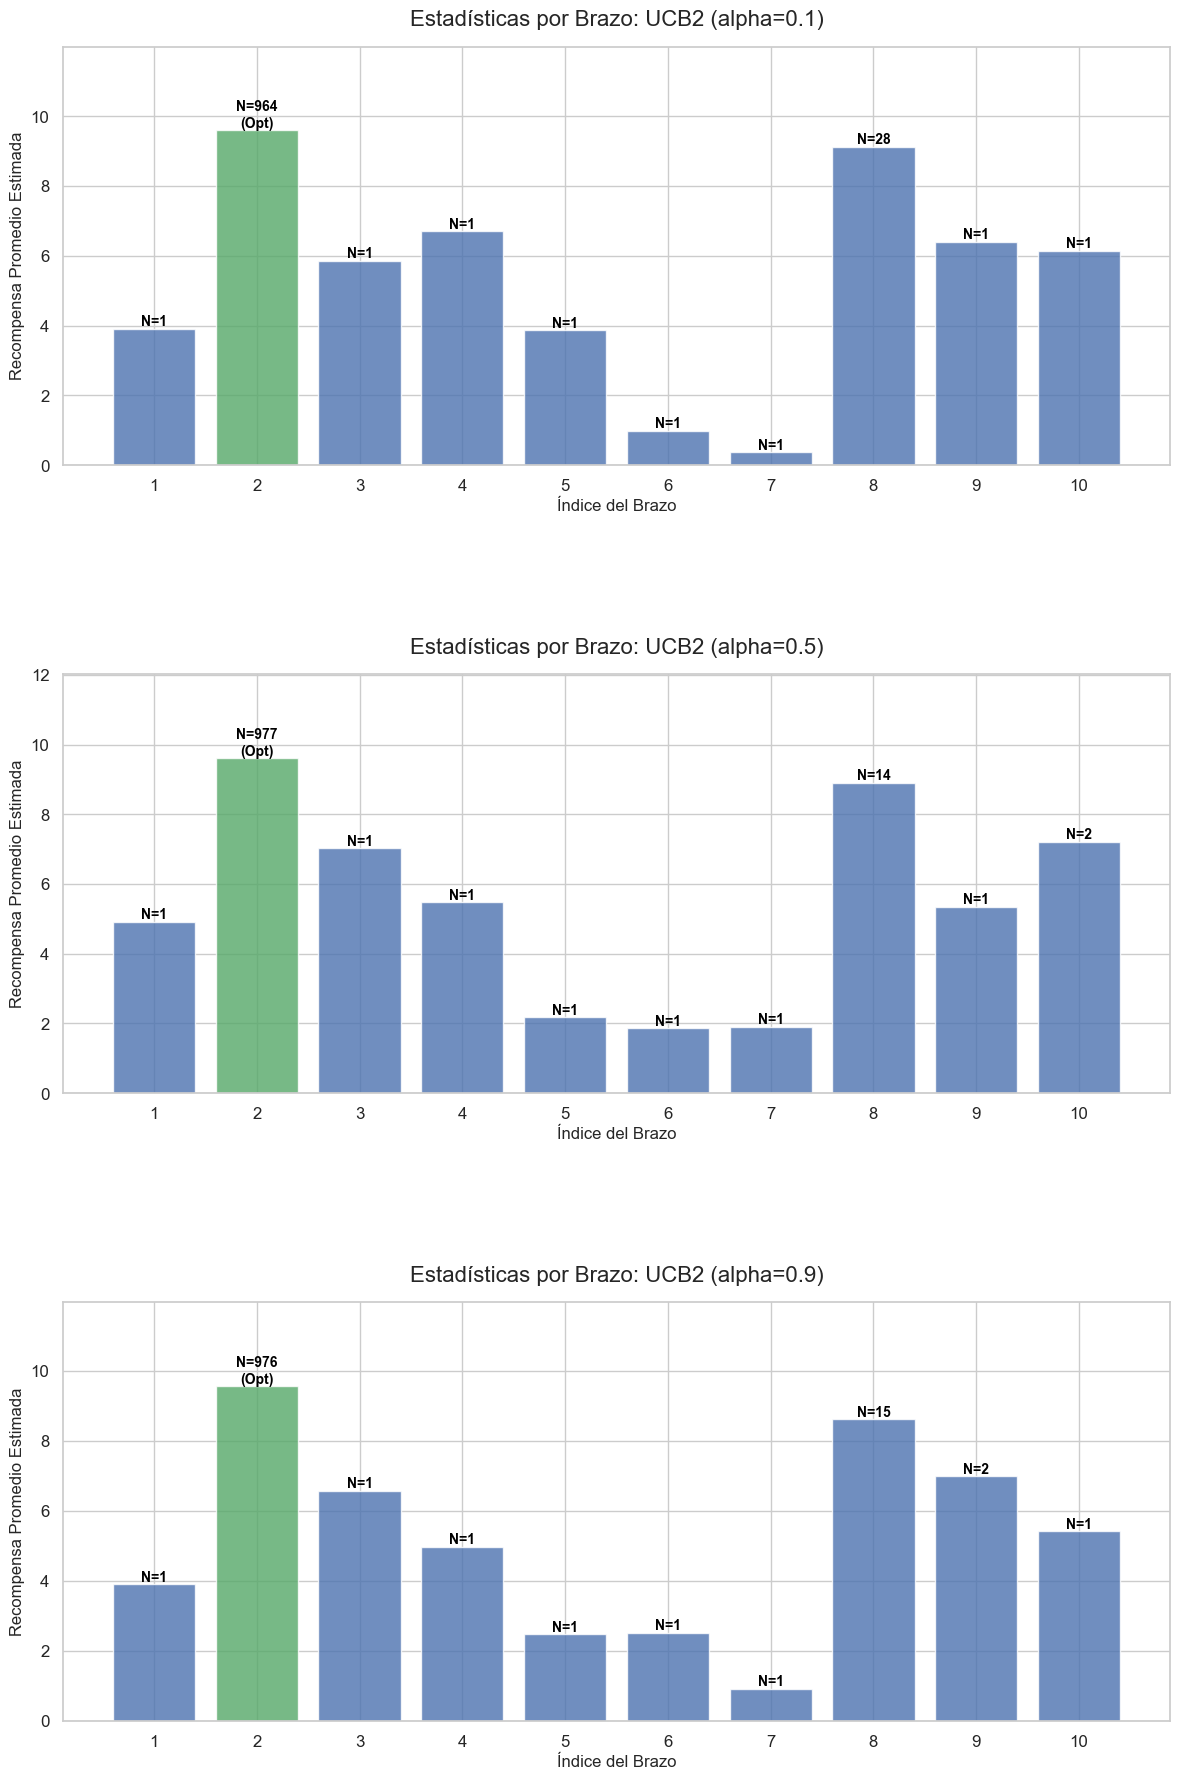

In [12]:
plot_arm_statistics(arms_stats, algorithms, optimal_arm_index)


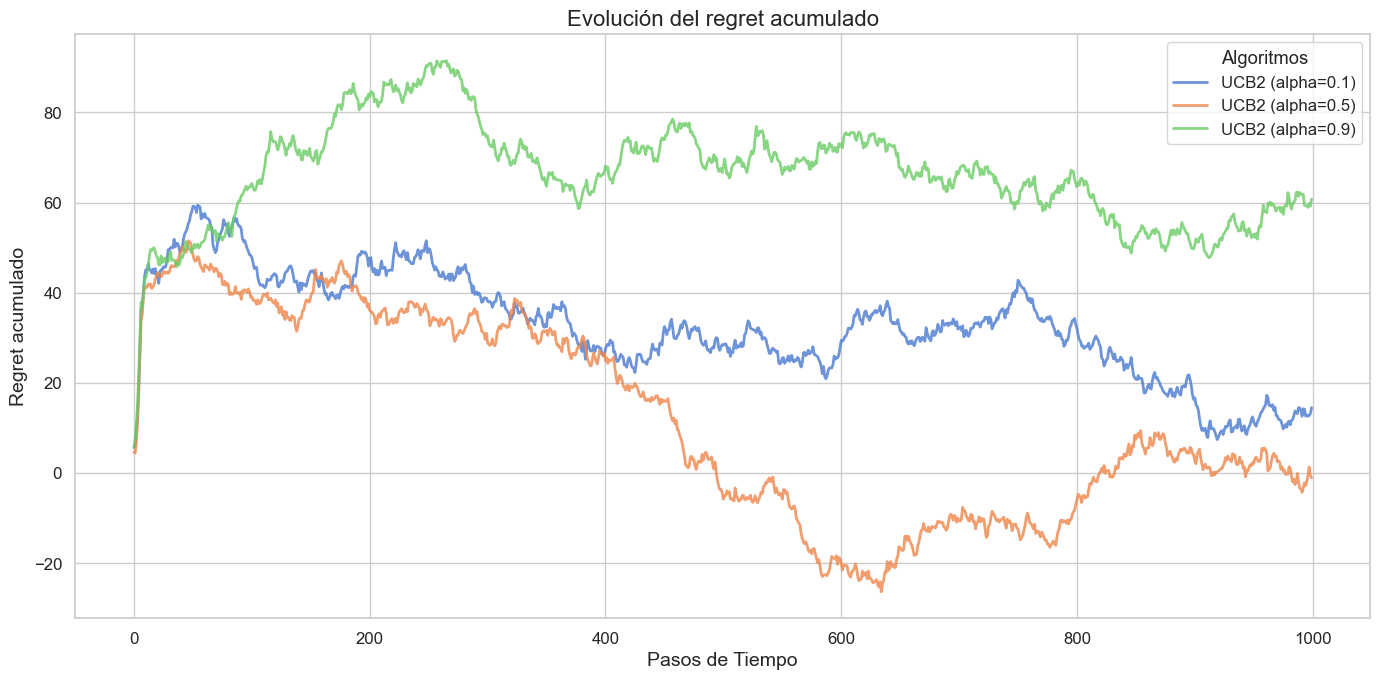

In [13]:
plot_regret(steps, regret_accumulated, algorithms)

c:\Users\Usuario\OneDrive\Desktop\MASTER\2do CUATRI\EML\Practicas\EML_MASTER\k_brazos\src\plotting\plotting.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Algoritmos')


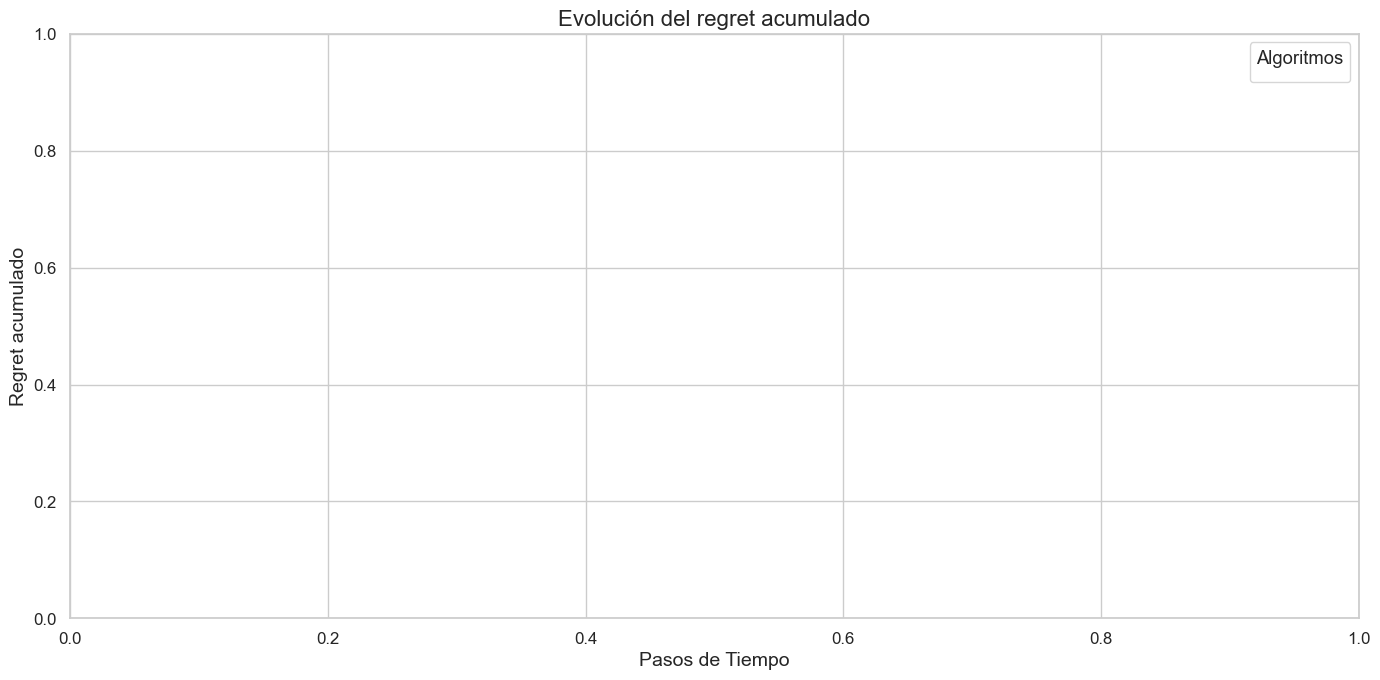

In [14]:
plot_regret(steps, regret_accumulated[4:], algorithms[4:])

### Experimento 2: Distribución Bernoulli

In [15]:
algorithms = [
                UCB2(k=k, alpha=0.001), 
                UCB2(k=k, alpha=0.01), 
                UCB2(k=k, alpha=0.1),
            ]

Bandit with 10 arms: ArmBernoulli(p=0.44), ArmBernoulli(p=0.96), ArmBernoulli(p=0.76), ArmBernoulli(p=0.64), ArmBernoulli(p=0.24), ArmBernoulli(p=0.24), ArmBernoulli(p=0.15), ArmBernoulli(p=0.88), ArmBernoulli(p=0.64), ArmBernoulli(p=0.74)
Optimal arm: 2 with expected reward=9.556428757689247
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
2
1
0
2
1
0
2
1
0
2
1
0
3
2
1
0
3
2
1
0
3
2
1
0
4
3
2
1
0
4
3
2
1
0
4
3
2
1
0
5
4
3
2
1
0
0
0
0
0
0
0
0
0
0
6
5
4
3
2
1
0
6
5
4
3
2
1
0
7
6
5
4
3
2
1
0
8
7
6
5
4
3
2
1
0
8
7
6
5
4
3
2
1
0
9
8
7
6
5
4
3
2
1
0
10
9
8
7
6
5
4
3
2
1
0
11
10
9
8
7
6
5
4
3
2
1
0
12
11
10
9
8
7
6
5
4
3
2
1
0
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
25
24


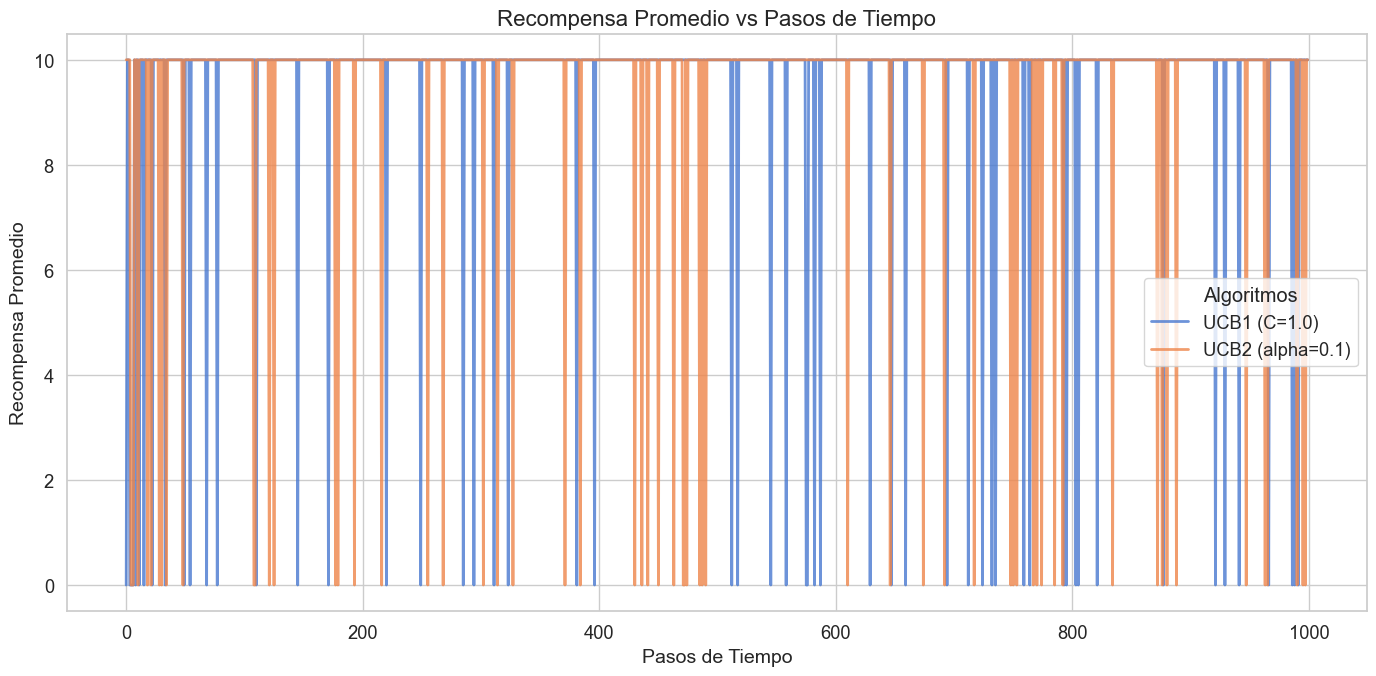

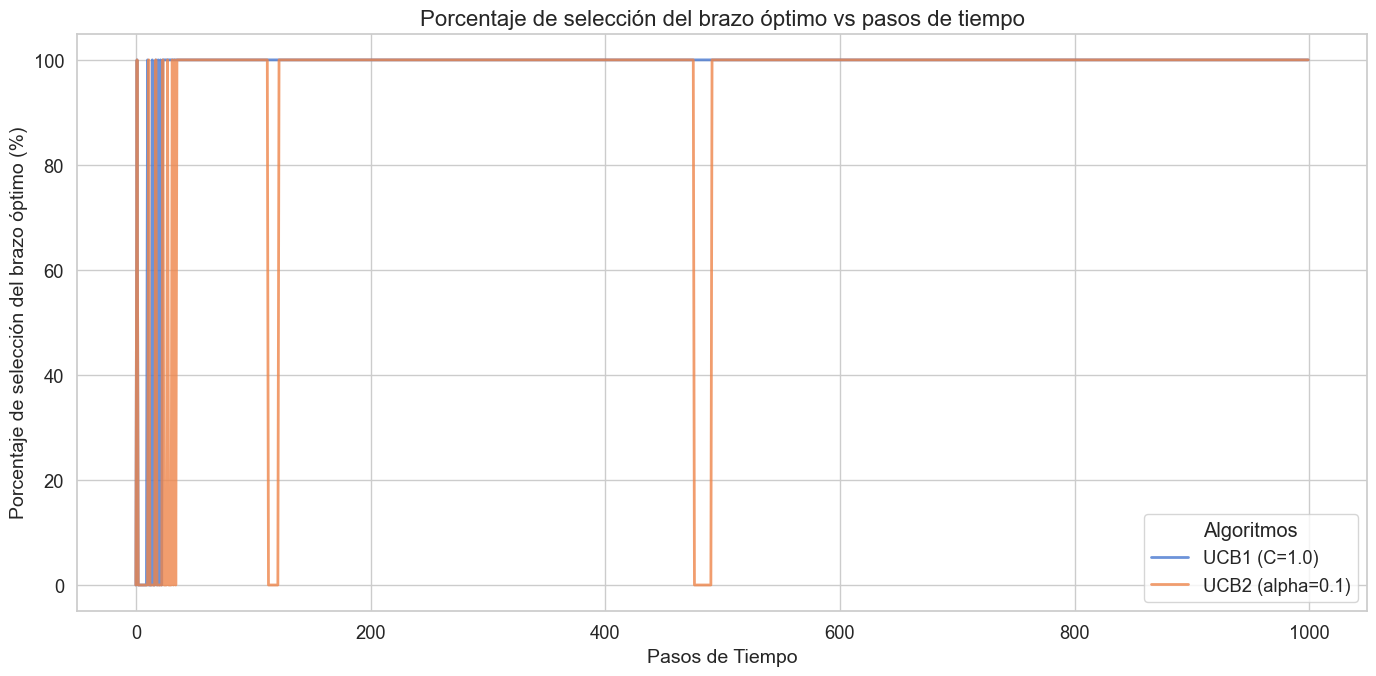

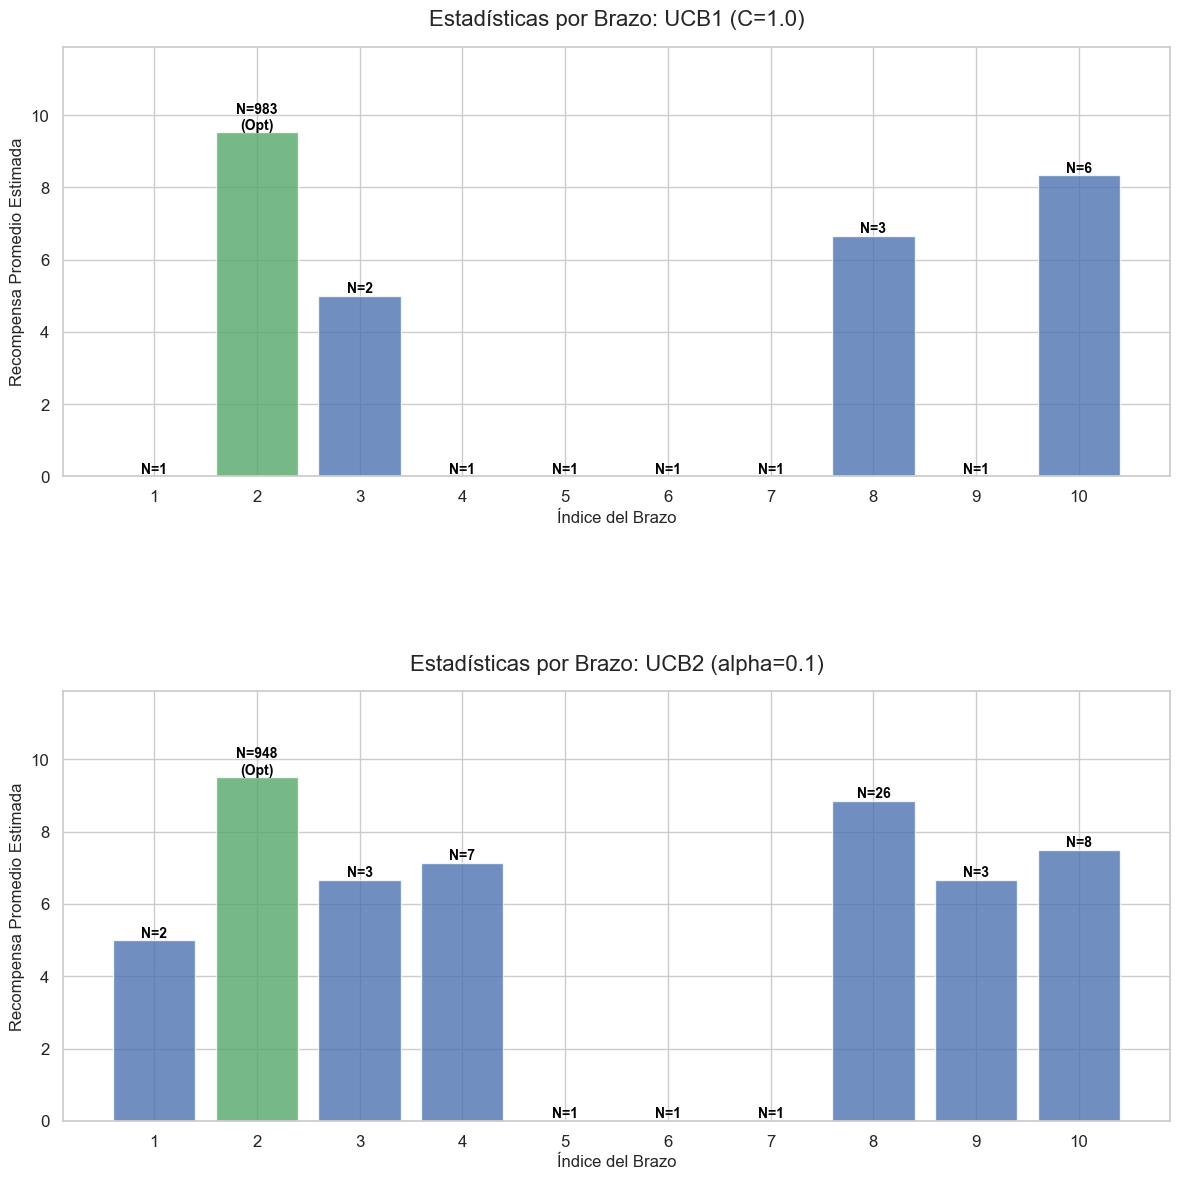

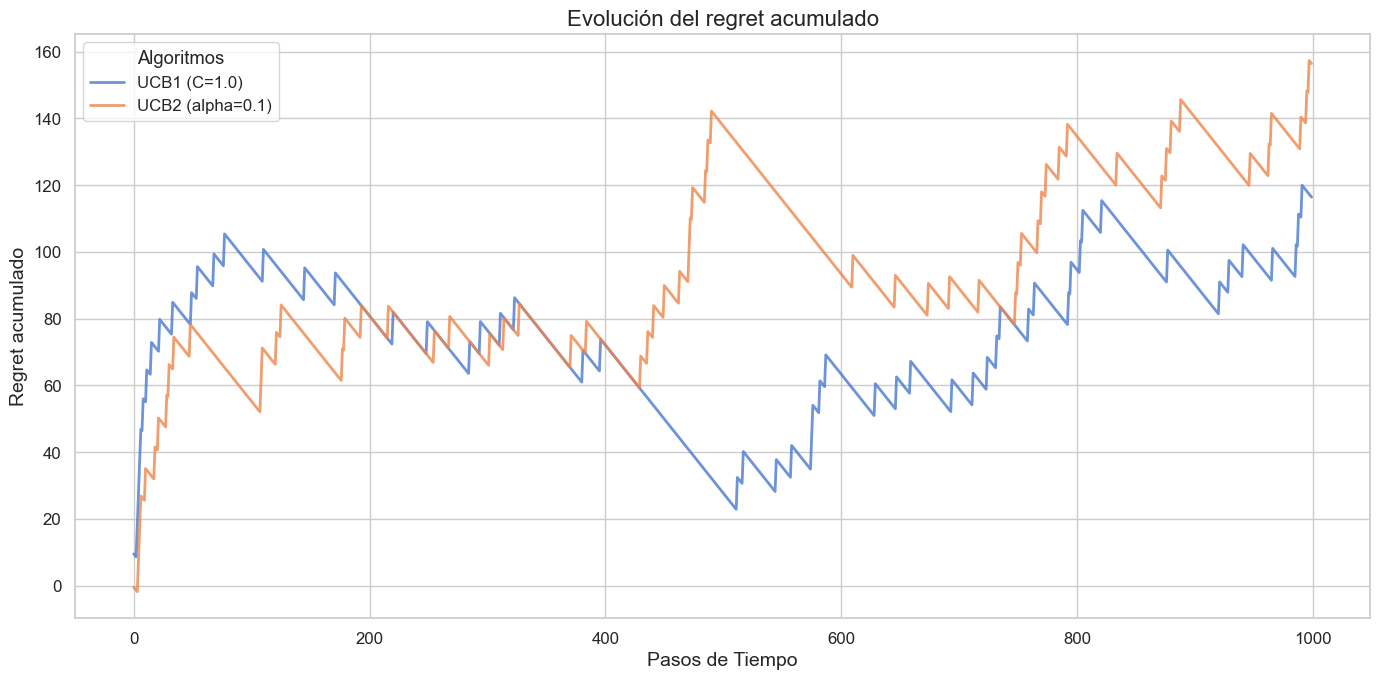

In [16]:
bandit = Bandit(arms=ArmBernoulli.generate_arms_with_fixed_means(means=means, scale = 10))  
# bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=10, scale = 1))
print(bandit)

# Obtiene el brazo óptimo para pasarlo a la gráfica
optimal_arm_index = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm_index + 1} with expected reward={bandit.get_expected_value(optimal_arm_index)}")

# Algoritmos para comparar
algorithms = [
                UCB1(k=k, c=1.0), 
                UCB2(k=k, alpha=0.1), 
            ]

# Ejecuta el experimento y obtiene las recompensas promedio y selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

# Genera las gráficas
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm_index)
plot_regret(steps, regret_accumulated, algorithms)

### Experimento 3: Distribución binomial

In [17]:
algorithms = [
                UCB2(k=k, alpha=0.001), 
                UCB2(k=k, alpha=0.01), 
                UCB2(k=k, alpha=0.1),
            ]

Bandit with 10 arms: ArmBinomial(n=10, p=0.44, scale=1), ArmBinomial(n=10, p=0.96, scale=1), ArmBinomial(n=10, p=0.76, scale=1), ArmBinomial(n=10, p=0.64, scale=1), ArmBinomial(n=10, p=0.24, scale=1), ArmBinomial(n=10, p=0.24, scale=1), ArmBinomial(n=10, p=0.15, scale=1), ArmBinomial(n=10, p=0.88, scale=1), ArmBinomial(n=10, p=0.64, scale=1), ArmBinomial(n=10, p=0.74, scale=1)
Optimal arm: 2 with expected reward=9.556428757689247
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
1
0
1
0
0
1
0
1
0
0
1
0
2
1
0
2
1
0
2
1
0
2
1
0
0
3
2
1
0
3
2
1
0
3
2
1
0
0
4
3
2
1
0
4
3
2
1
0
0
4
3
2
1
0
5
4
3
2
1
0
6
5
4
3
2
1
0
6
5
4
3
2
1
0
0
7
6
5
4
3
2
1
0
8
7
6
5
4
3
2
1
0
8
7
6
5
4
3
2
1
0
9
8
7
6
5
4
3
2
1
0
10
9
8
7
6
5
4
3
2
1
0
0
11
10
9
8
7
6
5
4
3
2
1
0
12
11
10
9
8
7
6
5
4
3
2
1
0
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
0
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2


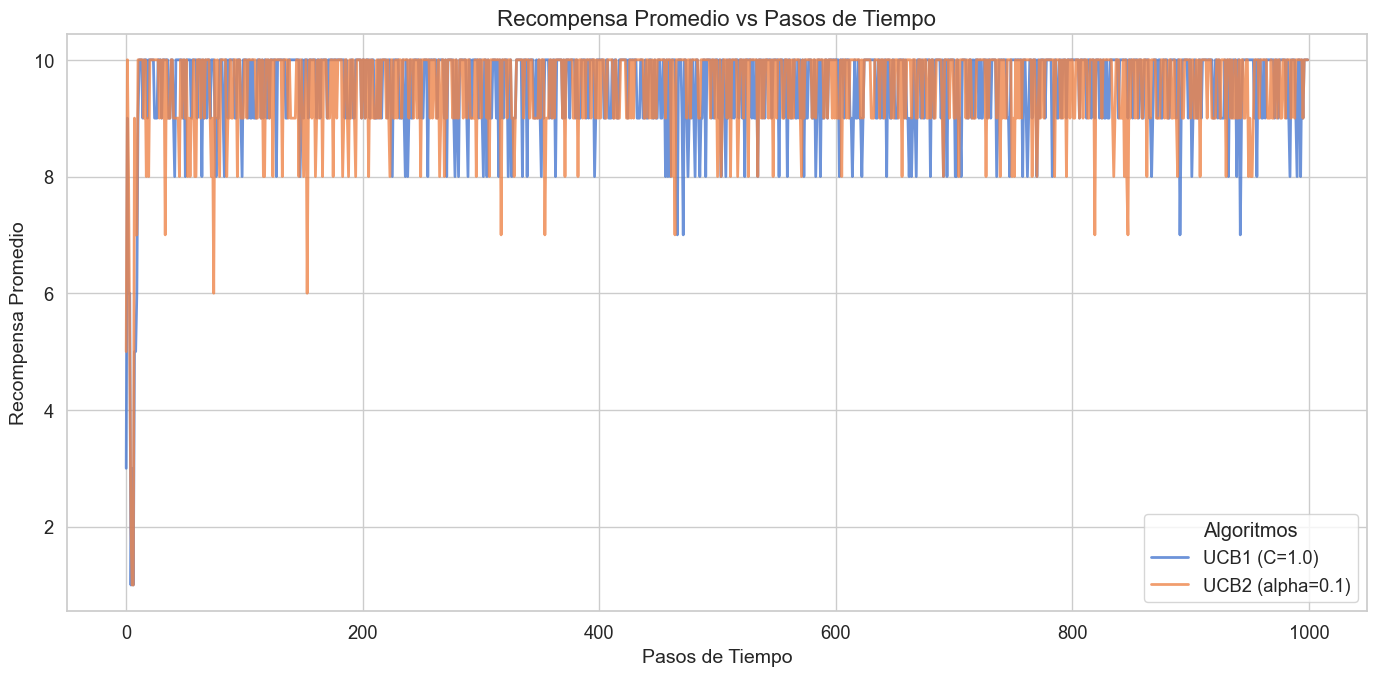

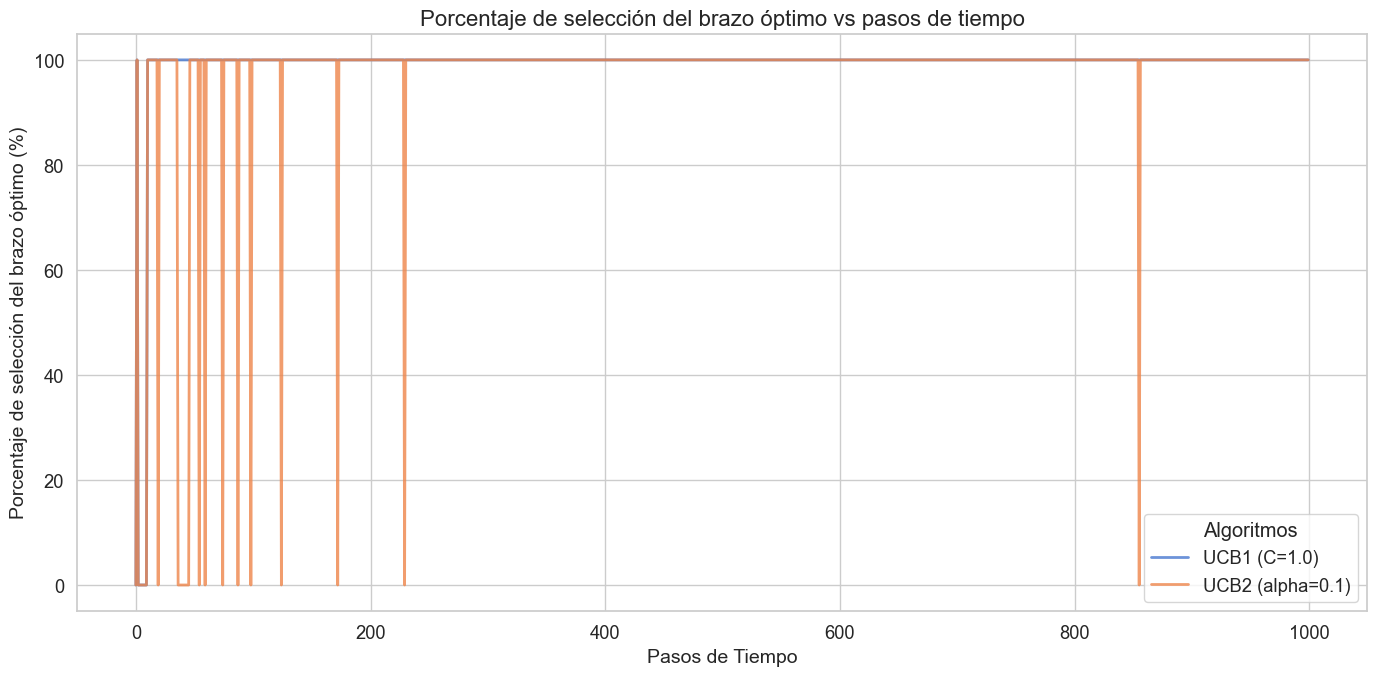

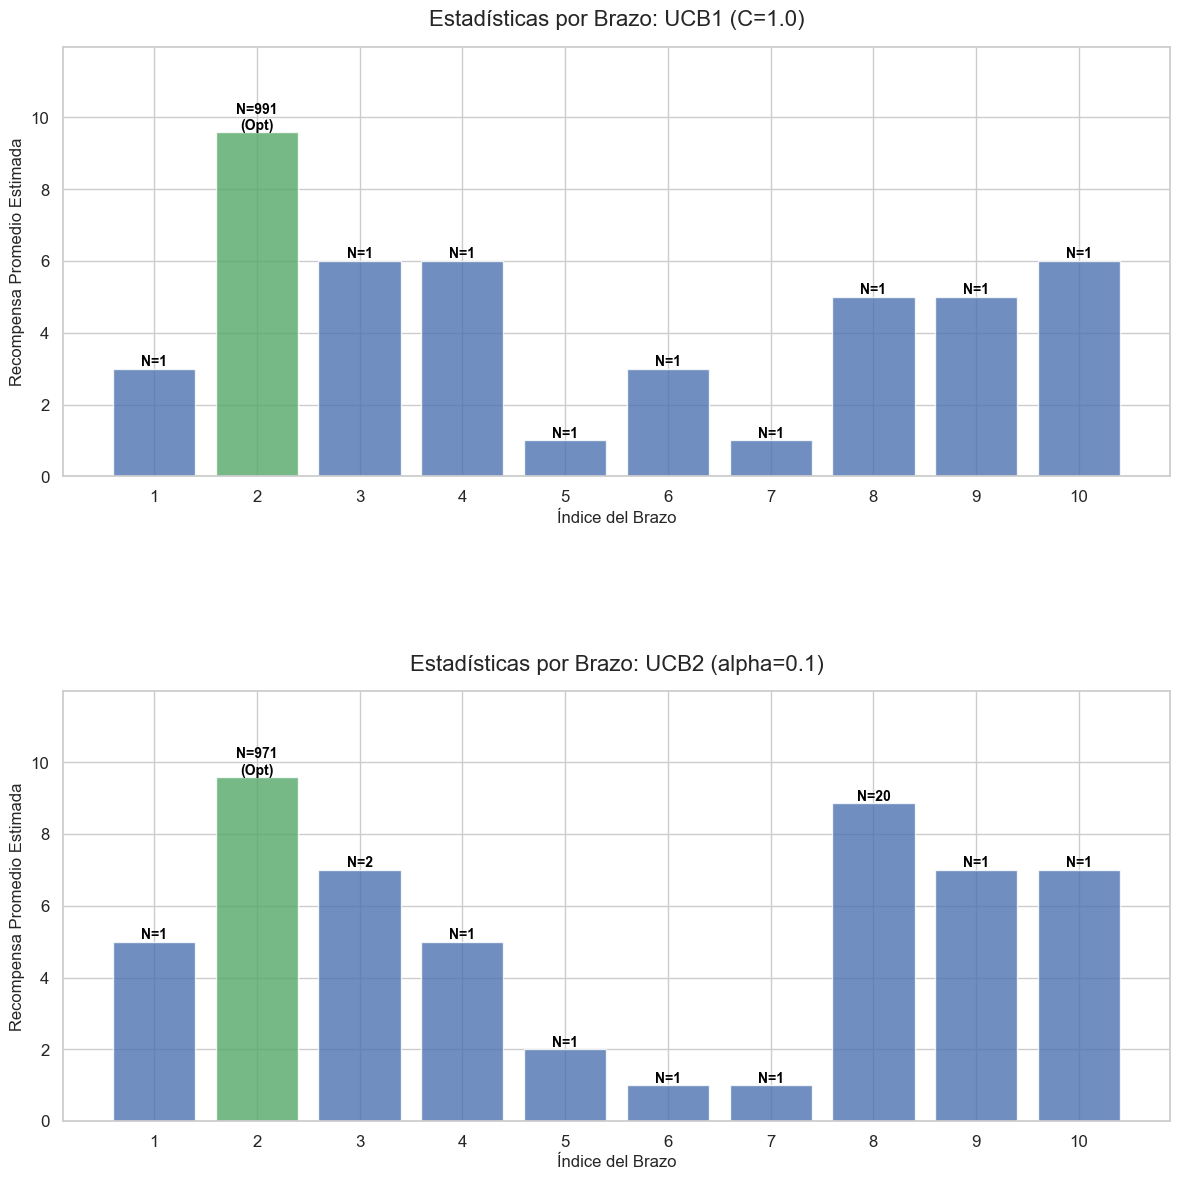

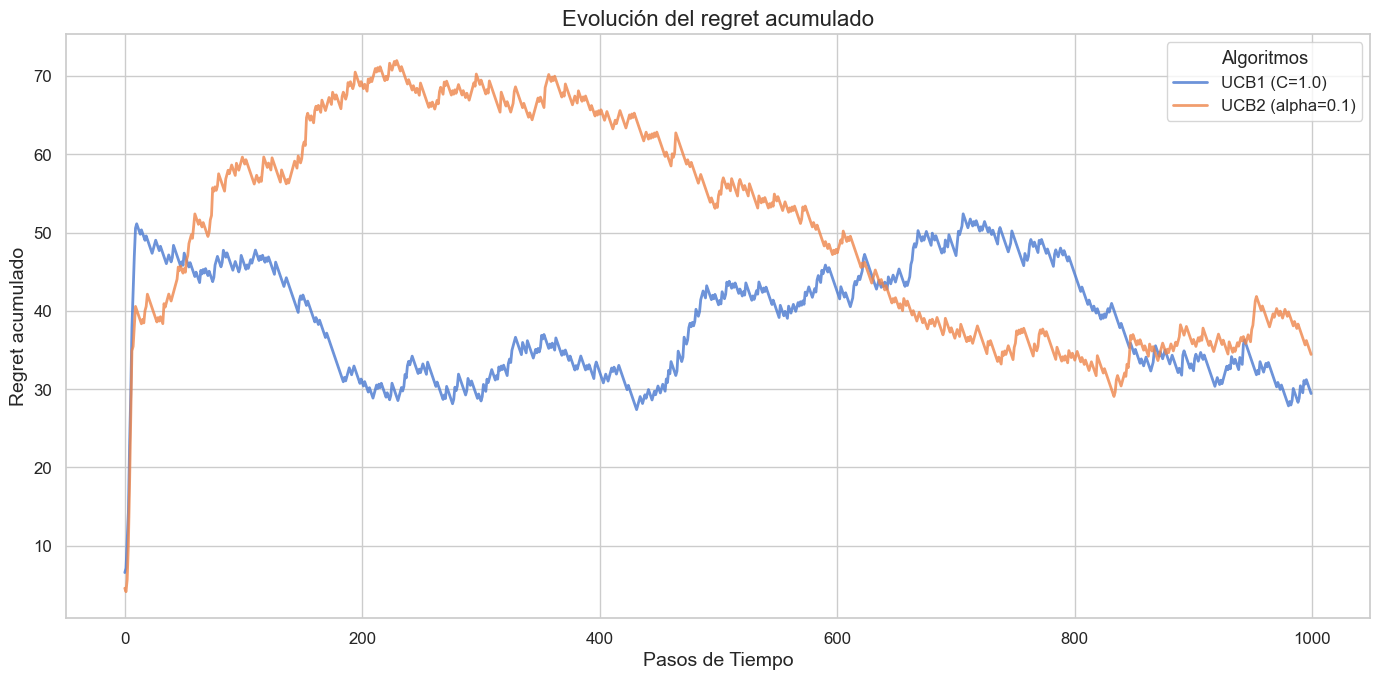

In [18]:
bandit = Bandit(arms=ArmBinomial.generate_arms_with_fixed_means(means=means, n=10, scale = 1))
print(bandit)

# Obtiene el brazo óptimo para pasarlo a la gráfica
optimal_arm_index = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm_index + 1} with expected reward={bandit.get_expected_value(optimal_arm_index)}")

# Algoritmos para comparar
algorithms = [
                UCB1(k=k, c=1.0), 
                UCB2(k=k, alpha=0.1), 
            ]

# Ejecuta el experimento y obtiene las recompensas promedio y selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

# Genera las gráficas
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm_index)
plot_regret(steps, regret_accumulated, algorithms)